In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/iriscsv/Iris.csv


In [2]:
# importing the Important Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [3]:
# Importing the Dataset
df = pd.read_csv("/kaggle/input/iriscsv/Iris.csv")
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


# Profile Report

In [4]:
from pandas_profiling import ProfileReport
ProfileReport(df)

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [5]:
# Dropping Unnecessary values
df.drop("Id",axis=1,inplace=True)

<Axes: >

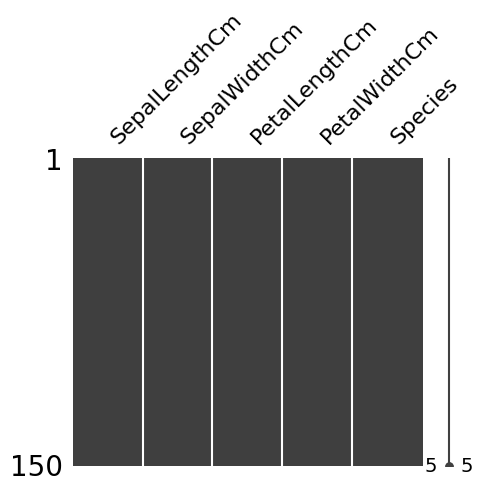

In [6]:
# Checking if any null values
import missingno as msno
msno.matrix(df,figsize=(5,4))

As there are no missing values we do not need to fill any values .

# 1. Exploratory Data Analysis


<Axes: ylabel='count'>

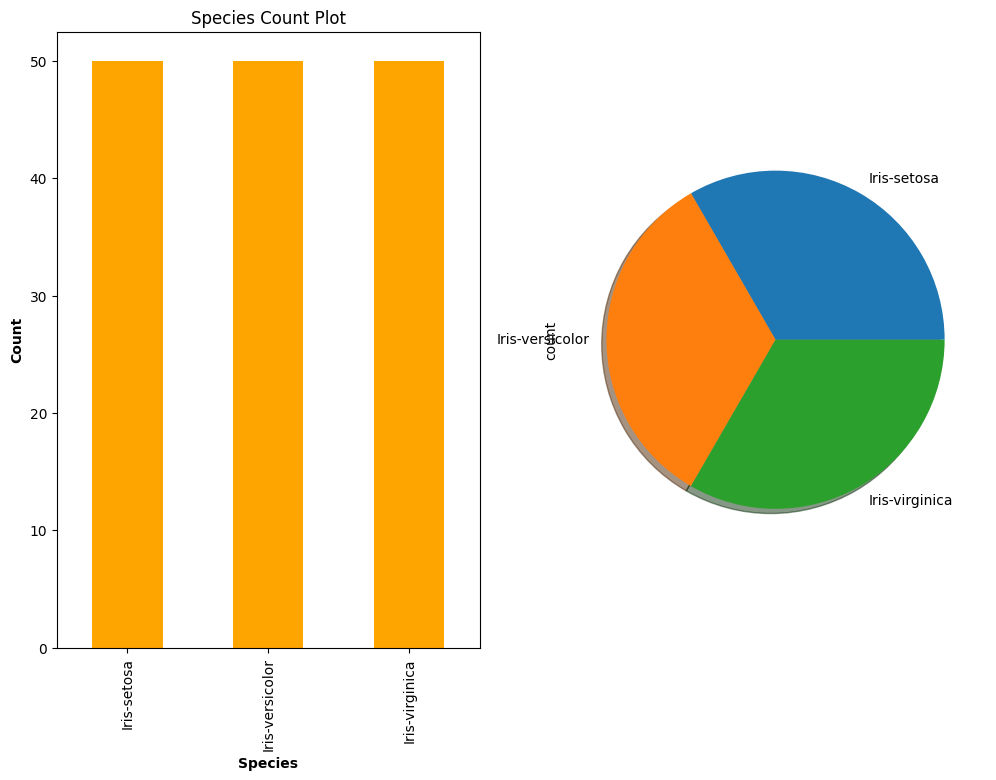

In [7]:
plt.figure(figsize=(12,8))
plt.subplot(1,2,1)
df["Species"].value_counts().plot(kind="bar",color="orange")
plt.title("Species Count Plot")
plt.xlabel("Species",fontweight="bold")
plt.ylabel("Count",fontweight="bold");
plt.subplot(1,2,2)
df["Species"].value_counts().plot(kind="pie",shadow=True)

In [8]:
plt.style.use("Solarize_Light2")
def Plot(dataset,features):
    plt.figure(figsize=(12,8))
    plt.subplot(1,2,1)
    sns.distplot(dataset[features],bins=30,color="orange")
    plt.title(f"{features} DistPlot")
    plt.xlabel(f"{features}",fontweight="bold")
    plt.ylabel("Density",fontweight="bold")
    # Checking if any outliers    
    plt.subplot(1,2,2)
    sns.boxplot(df[features],color="orange")
    plt.xlabel(f"{features}")
    plt.ylabel("Count")
    plt.title("Boxplot of {}".format(features))

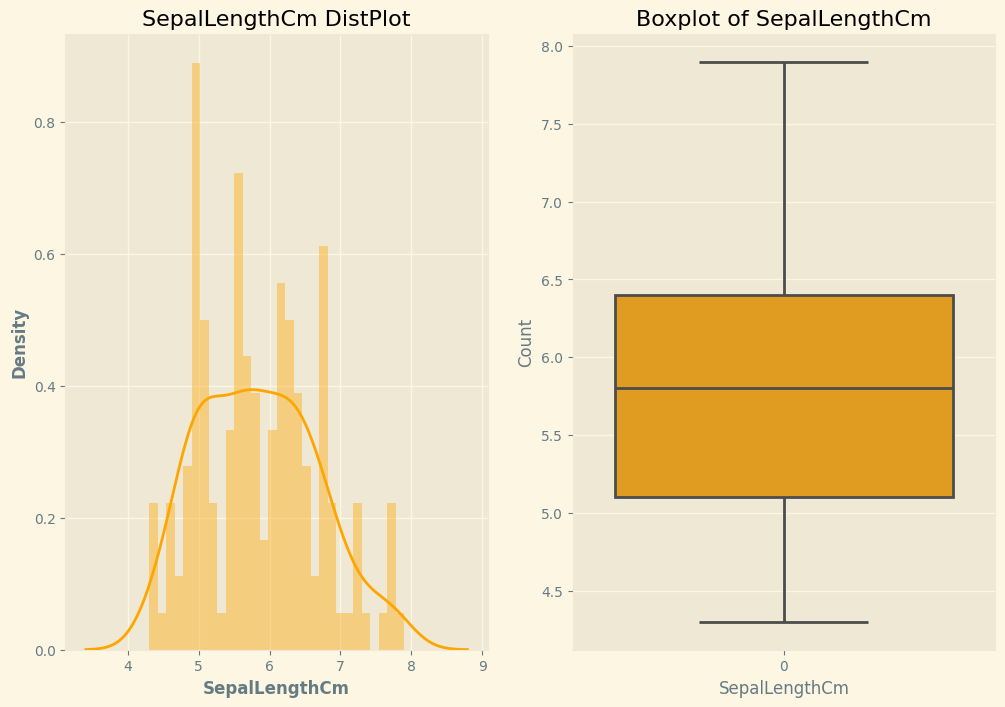

In [9]:
Plot(df,"SepalLengthCm")

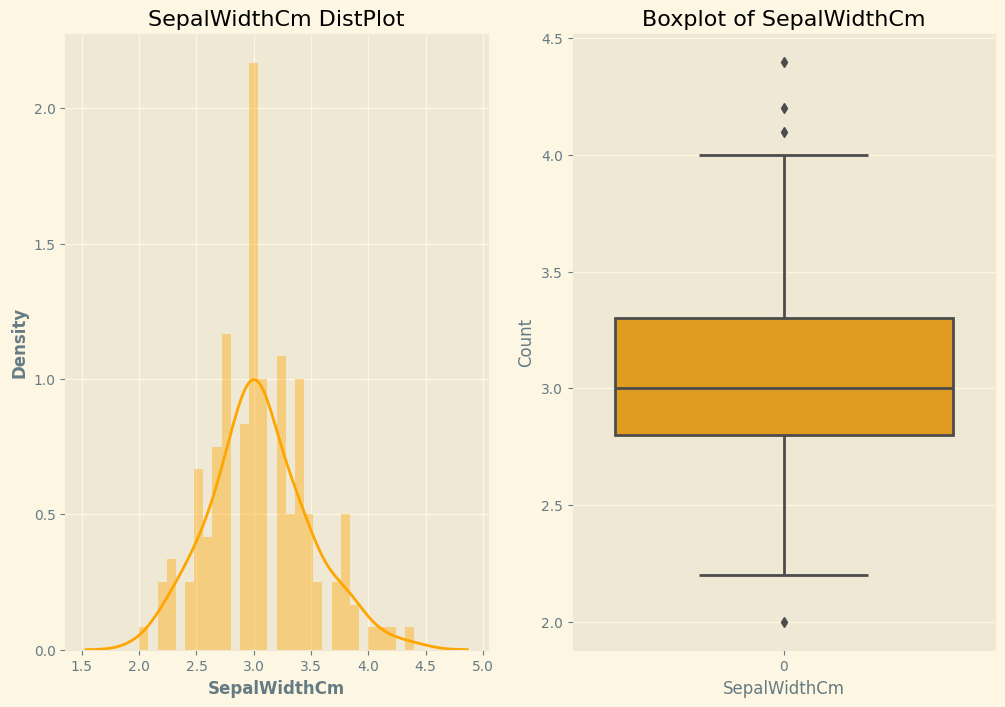

In [10]:
Plot(df,"SepalWidthCm")

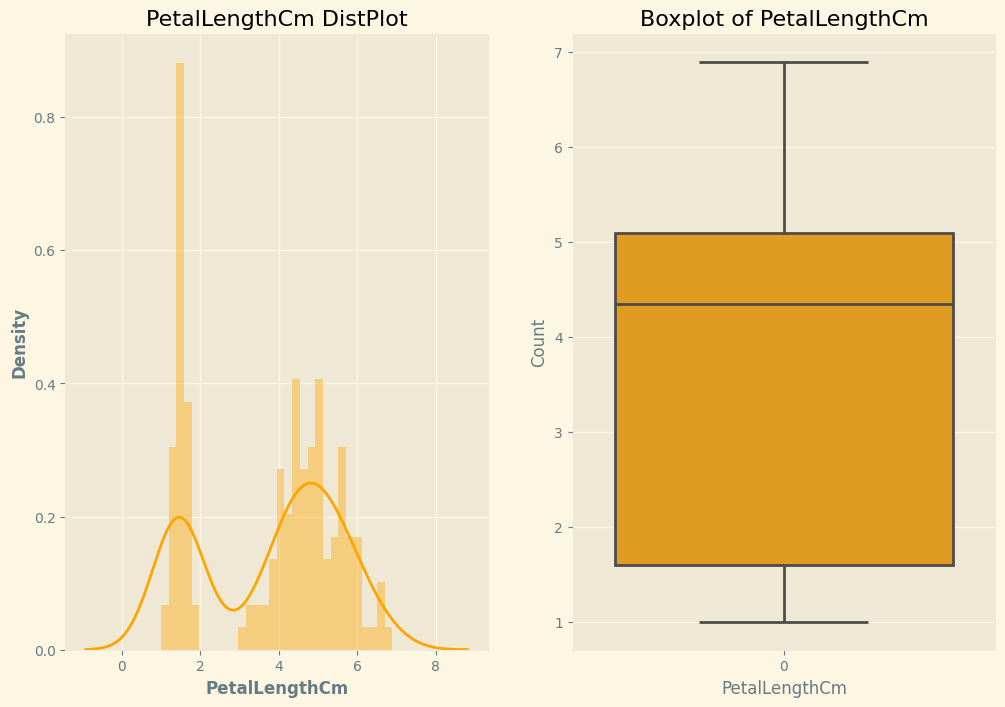

In [11]:
Plot(df,"PetalLengthCm")

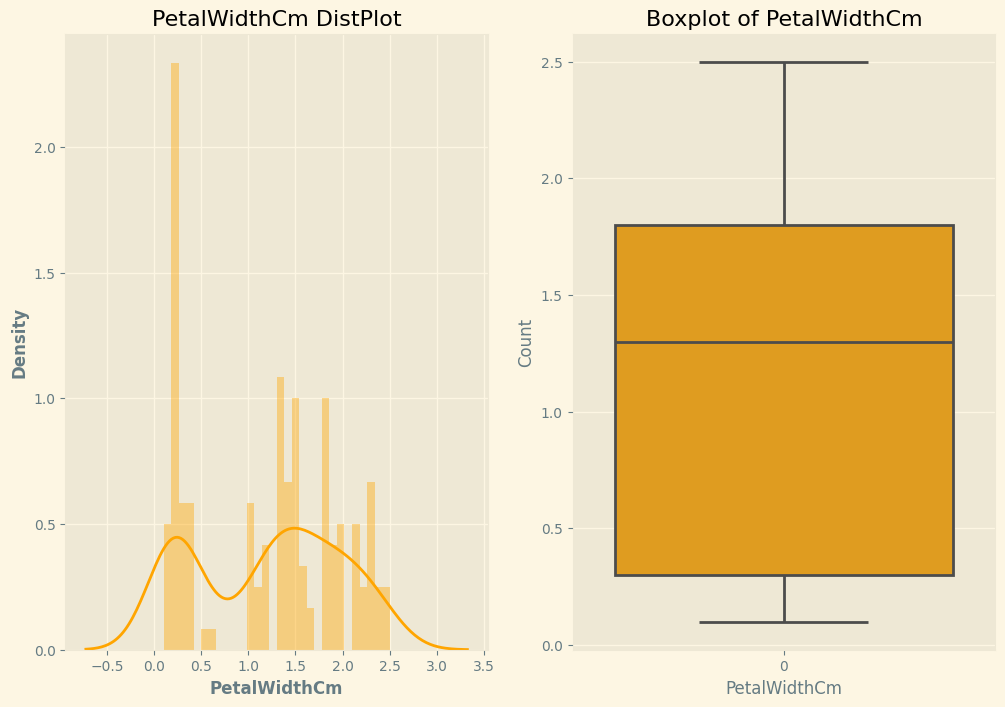

In [12]:
Plot(df,"PetalWidthCm")

# 2. Scatter plot of Two Columns

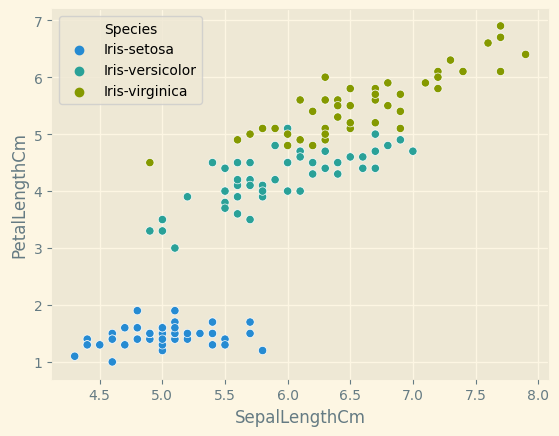

In [13]:
sns.scatterplot(data=df,x="SepalLengthCm",y="PetalLengthCm",hue="Species");

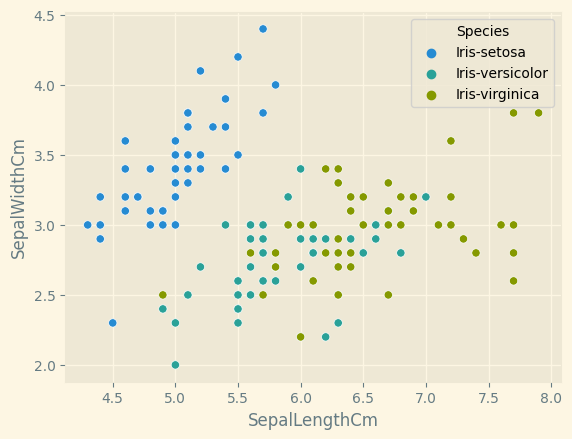

In [14]:
sns.scatterplot(data=df,x="SepalLengthCm",y="SepalWidthCm",hue="Species");

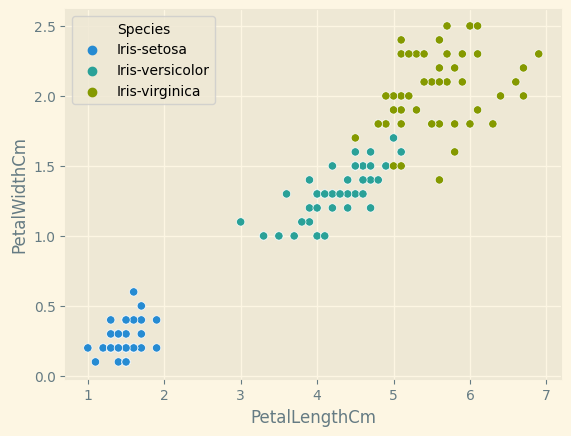

In [15]:
sns.scatterplot(data=df,x="PetalLengthCm",y="PetalWidthCm",hue="Species");

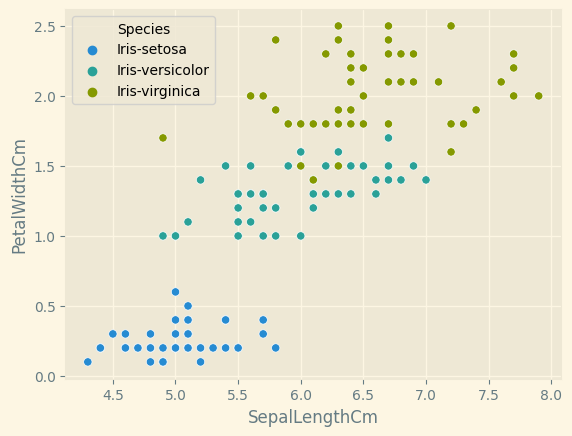

In [16]:
sns.scatterplot(data=df,x="SepalLengthCm",y="PetalWidthCm",hue="Species");

# 3. Correlation

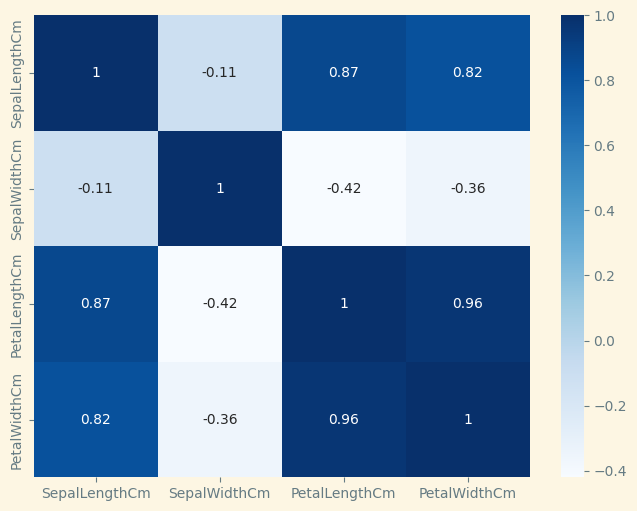

In [17]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap="Blues");

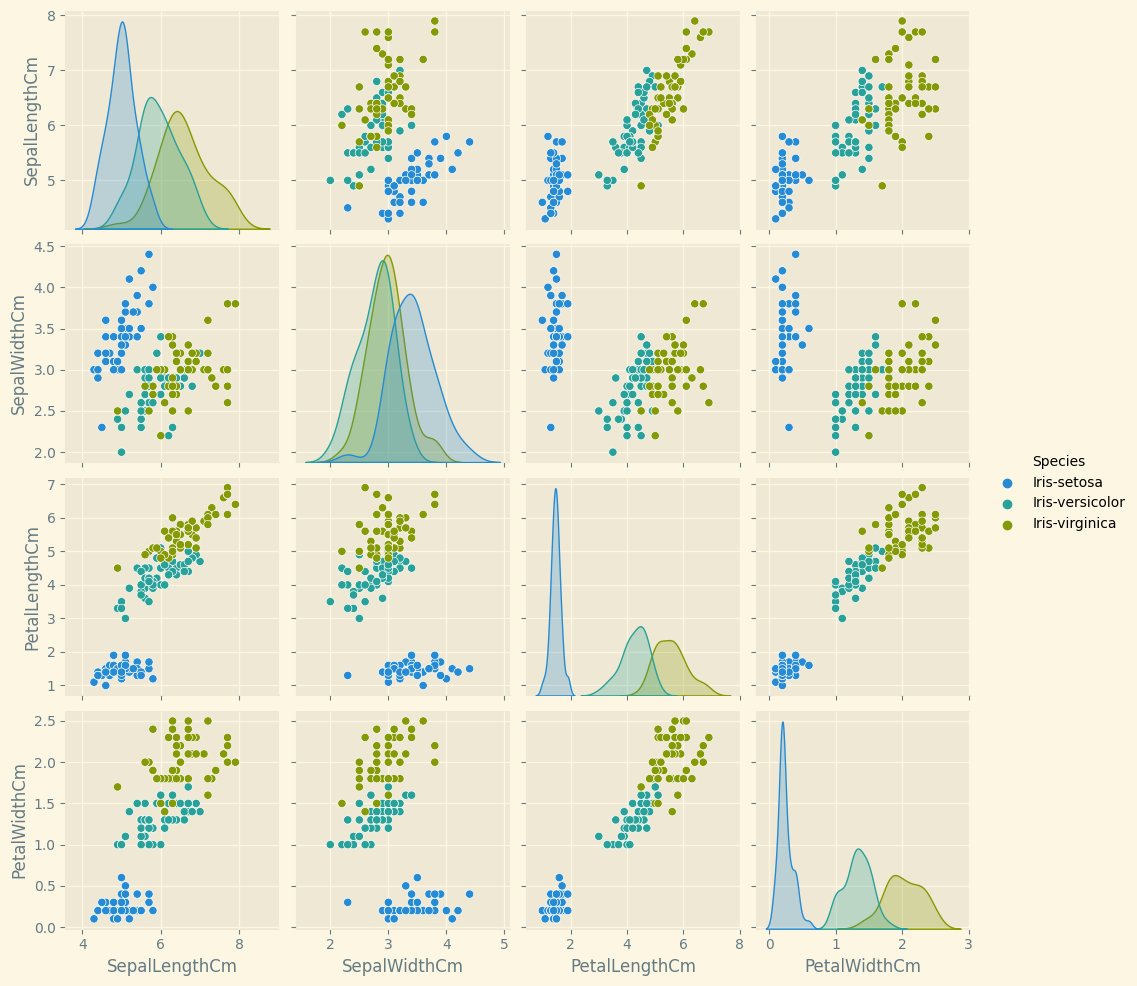

In [18]:
sns.pairplot(df,hue="Species")

In [19]:
# Converting Categorical into Numerical Columns
mapping = {"Iris-setosa":0,"Iris-versicolor":1,"Iris-virginica":2}
df["Species"] = df["Species"].map(mapping)

# Splitting the Data `

In [20]:
X = df.drop("Species",axis=1)
y = df["Species"]
np.random.seed(42)
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test  = train_test_split(X,y,test_size=0.3,random_state=33)
print("The shape of X_train is :",X_train.shape)
print("The shape of X_test is :",X_test.shape)
print("The shape of y_train is :",y_train.shape)
print("The shape of y_test is :",y_test.shape)


The shape of X_train is : (105, 4)
The shape of X_test is : (45, 4)
The shape of y_train is : (105,)
The shape of y_test is : (45,)


# Modelling

In [21]:
# Importing all the models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

In [22]:
models = [("LR" ,LogisticRegression()),("DTR" ,DecisionTreeClassifier()),("RFC" , RandomForestClassifier()),("KNN",KNeighborsClassifier())]


In [23]:
# Importing important Classification metrics
from sklearn.metrics import confusion_matrix,precision_score,f1_score,accuracy_score,classification_report


In [24]:
for name,model in models:
    model.fit(X_train,y_train)
    y_pred = model.predict(X_test)
    print(f"====================={model}=====================")

    print(f"The precision score of the model {model} is :",{precision_score(y_test,y_pred,average="weighted")})
    print(f"The F1 score of the model {model} is :",({np.round(f1_score(y_test,y_pred,average="weighted"),2)*100}))
    print(f"The Accuracy of the model is {model} is :",{(np.round(accuracy_score(y_test,y_pred),2))*100})
    print("-"*64)
    print((classification_report(y_pred,y_test)))
    
    print("="*100)
    
    

=====================LogisticRegression()=====================
The precision score of the model LogisticRegression() is : {0.9444444444444444}
The F1 score of the model LogisticRegression() is : {93.0}
The Accuracy of the model is LogisticRegression() is : {93.0}
----------------------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       1.00      0.83      0.91        18
           2       0.84      1.00      0.91        16

    accuracy                           0.93        45
   macro avg       0.95      0.94      0.94        45
weighted avg       0.94      0.93      0.93        45

=====================DecisionTreeClassifier()=====================
The precision score of the model DecisionTreeClassifier() is : {0.9298245614035088}
The F1 score of the model DecisionTreeClassifier() is : {91.0}
The Accuracy of the model is DecisionTreeClassifier() is : {91.0}
----------

# Hyperparamter Tuning

# 1. Logistic Regression

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
grid = {"C":np.logspace(2,10),"penalty":["l1","l2"]}
LR = LogisticRegression()
LR_cv = GridSearchCV(LR,grid,cv=10)
LR_cv.fit(X_train,y_train)
print("The best parameters are :",LR_cv.best_params_)

The best parameters are : {'C': 100.0, 'penalty': 'l2'}


In [26]:
LR_HT = LogisticRegression(C=100,penalty="l2")
LR_HT.fit(X_train,y_train)
y_pred = LR_HT.predict(X_test)
LR_HT_score = (accuracy_score(y_test,y_pred)*100)
print("The model prediction after model tuning is :",(accuracy_score(y_test,y_pred)*100),"%")


The model prediction after model tuning is : 100.0 %


In [27]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       1.00      1.00      1.00        15
           2       1.00      1.00      1.00        19

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



# 2. Decision Tree Classifier

In [28]:
import time
%time
from sklearn.model_selection import GridSearchCV

param_grid = {'max_features': ['auto', 'sqrt', 'log2'],
              'ccp_alpha': [0.1, .01, .001],
              'max_depth' : [5, 6, 7, 8, 9],
              'criterion' :['gini', 'entropy'],
              'max_features' : [1,3,5,7]
             }
DTC = DecisionTreeClassifier(random_state=100)
grid_search = GridSearchCV(estimator=DTC, param_grid=param_grid, cv=8, verbose=True)
grid_search.fit(X_train, y_train)

CPU times: user 3 µs, sys: 1 µs, total: 4 µs
Wall time: 8.58 µs
Fitting 8 folds for each of 120 candidates, totalling 960 fits


GridSearchCV(cv=8, estimator=DecisionTreeClassifier(random_state=100),
             param_grid={'ccp_alpha': [0.1, 0.01, 0.001],
                         'criterion': ['gini', 'entropy'],
                         'max_depth': [5, 6, 7, 8, 9],
                         'max_features': [1, 3, 5, 7]},
             verbose=True)

In [29]:
grid_search.best_params_

{'ccp_alpha': 0.1, 'criterion': 'gini', 'max_depth': 5, 'max_features': 1}

In [30]:
DTR_HT = DecisionTreeClassifier(ccp_alpha= 0.001, criterion= 'gini', max_depth= 5, max_features= 1)
DTR_HT.fit(X_train,y_train)
y_pred = DTR_HT.predict(X_test)
DHT_score = np.round(accuracy_score(y_test,y_pred),2)*100
print(DHT_score)

93.0


# 3. Random Forest Classifier


In [31]:
from sklearn.model_selection import GridSearchCV 
grid = {
    'bootstrap': [True],
    'max_depth': [90, 100, 110],
    'max_features': [2, 3],
    'min_samples_leaf': [3, 4, 5],
    'min_samples_split': [8, 10, 12],
    'n_estimators': [100, 200, 300, 1000]
}
RFC = RandomForestClassifier()
RFC_HT = GridSearchCV(RFC,grid,cv=5,verbose=True,n_jobs=-1)
RFC_HT.fit(X_train,y_train)
RFC_HT.best_params_

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


{'bootstrap': True,
 'max_depth': 90,
 'max_features': 2,
 'min_samples_leaf': 3,
 'min_samples_split': 8,
 'n_estimators': 100}

In [32]:
RFC = RandomForestClassifier(bootstrap= True,
 max_depth= 90,
 max_features= 2,
 min_samples_leaf= 3,
 min_samples_split= 8,
 n_estimators= 100)
RFC.fit(X_train,y_train)
y_pred_RFC = RFC.predict(X_test)
RFC_accuracy = np.round(accuracy_score(y_test,y_pred_RFC),2)*100
RFC_accuracy

96.0

# 4. KNN Classifiers

In [33]:
grid_params = { 'n_neighbors' : [5,7,9,11,13,15],
               'weights' : ['uniform','distance'],
               'metric' : ['minkowski','euclidean','manhattan']}
KNN = KNeighborsClassifier()
KNN_grid  = GridSearchCV(KNN,grid_params,verbose=1,n_jobs=-1,cv=3)
KNN_grid.fit(X_train,y_train)
y_pred = KNN_grid.predict(X_test)
KNN_accuracy = np.round(accuracy_score(y_test,y_pred),2)*100
KNN_accuracy


Fitting 3 folds for each of 36 candidates, totalling 108 fits


98.0

In [34]:
# Accuracy Evaluation in a dataframe
Model_fit = [["LR",LR_HT_score],["DTR",DHT_score],["RFC" ,RFC_accuracy],["KNN" , KNN_accuracy]]
accuracy_df = pd.DataFrame(data=Model_fit,columns=["MODELS","ACCURACY"])
accuracy_df

,MODELS,ACCURACY
0,LR,100.0
1,DTR,93.0
2,RFC,96.0
3,KNN,98.0


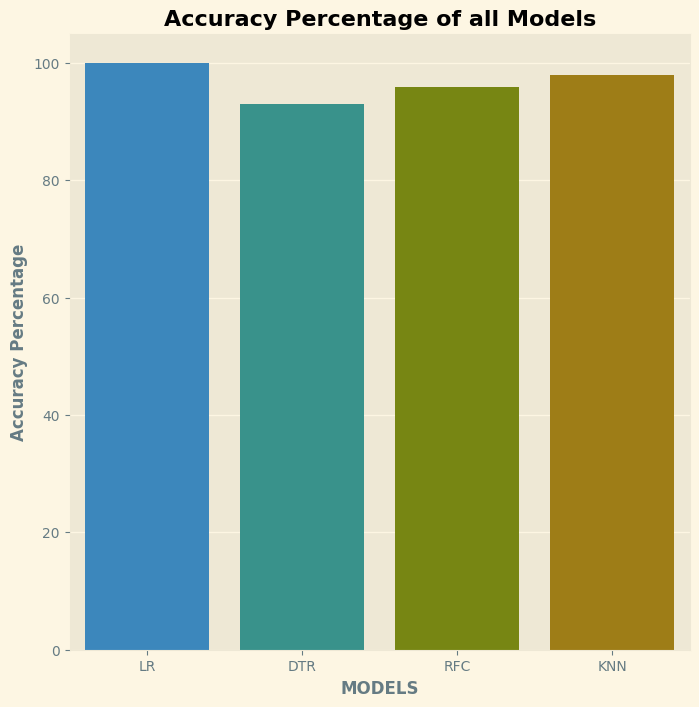

In [35]:
plt.figure(figsize=(8,8))
sns.barplot(data=accuracy_df,x="MODELS",y="ACCURACY")
plt.title("Accuracy Percentage of all Models",fontweight="bold")
plt.xlabel("MODELS",fontweight="bold")
plt.ylabel("Accuracy Percentage",fontweight="bold");